# Percobaan 3

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Kode di atas digunakan untuk menghubungkan Google Drive dengan lingkungan kerja Google Colab agar file yang tersimpan di dalam Google Drive dapat diakses secara langsung selama proses pengolahan data, seperti file Percobaan 1 dan Percobaan 2. Kode `from google.colab import drive` digunakan untuk mengimpor modul `drive` dari pustaka `google.colab`, sedangkan perintah `drive.mount('/content/drive')` berfungsi untuk melakukan mounting atau menghubungkan Google Drive ke direktori `/content/drive` pada Google Colab.

# Lokasi Dataset

In [11]:
healthy_path = "/content/drive/MyDrive/PCD_Project/dataset/healthy"
diseased_path = "/content/drive/MyDrive/PCD_Project/dataset/diseased"

Kode di atas untuk menghungkan lokasi data yang ada di Google Drive. Meskipun data gambar sudah dimuat secara berantai dari notebook percobaan sebelumnya melalui perintah `%run`, pendefinisian `healthy_path` dan `diseased_path` di awal Percobaan 3 ini tetap digunakan untuk memastikan sinkronisasi lokasi data yang konsisten pada direktori Google Drive, mendokumentasikan struktur folder agar mudah diperbarui jika terjadi perubahan, serta memperjelas alur logika pengondisian indeks kategori (*Healthy* dan *Diseased*) saat visualisasi data dilakukan.

# Pemanggilan Notebook Percobaan 2

In [12]:
percobaan2 = "/content/drive/MyDrive/PCD_Project/percobaan/Percobaan2.ipynb"
%run $percobaan2

Output hidden; open in https://colab.research.google.com to view.

Kode di atas digunakan untuk memuat dan menjalankan seluruh isi notebook **Percobaan 2** ke dalam **Percobaan 3**, sehingga semua library (seperti OpenCV, NumPy, Matplotlib), variabel data citra yang telah dibaca, serta fungsi-fungsi yang telah didefinisikan sebelumnya otomatis aktif di memori dan langsung bisa digunakan kembali tanpa perlu menulis ulang kodenya dari awal.

# Menampilkan Hasil Prepo2 (Sobel dan Thresholding)

In [13]:
show_images(healthy_idxs, "Healthy (80 samples)")
show_images(diseased_idxs, "Diseased (80 samples)")

Output hidden; open in https://colab.research.google.com to view.

Kode di atas berfungsi untuk memanggil fungsi `show_images` guna menampilkan visualisasi grid gambar (maksimal 80 sampel) dari masing-masing kategori kelas secara terpisah, yang bertujuan untuk memvalidasi apakah hasil akhir proses *preprocessing* dari Percobaan 2 sudah seragam dan benar, sekaligus memudahkan analisis komparatif karakteristik visual antara tanaman yang sehat (*Healthy*) dan yang terserang penyakit (*Diseased*) sebelum melangkah ke tahap deteksi tepi.

In [20]:
# kernel sobel sumbu x / x-axis sobel kernel
sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)
# kernel sobel sumbu y / y-axis sobel kernel
sobelY = np. array([
    [ 1, 2, 1],
    [ 0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

Kode di atas berfungsi untuk mendefinisikan matriks kernel (mask) berukuran 3×3 yang digunakan sebagai filter dalam operasi deteksi tepi Sobel. Variabel sobelX dirancang dengan bobot horizontal untuk mendeteksi perubahan intensitas piksel searah sumbu-X (menonjolkan garis/tepi vertikal), sedangkan variabel sobelY dirancang dengan bobot vertikal untuk mendeteksi perubahan intensitas searah sumbu-Y (menonjolkan garis/tepi horizontal). Kedua kernel ini nantinya akan diaplikasikan pada citra tanaman melalui fungsi konvolusi untuk mengekstraksi struktur bentuk dan pola garis tepi luar pada daun secara detail, sebelum akhirnya digabungkan untuk mendapatkan hasil magnitudo gradien tepi yang utuh.

# Menampilkan Hasil Sobel

In [21]:
# Fungsi Konvolusi - Menghitung konvolusi antara citra dan kernel
def Konvolusi(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

# Fungsi Deteksi Tepi - Menggunakan operator Sobel
def edge(img, kernelx, kernely):
    gx = Konvolusi(img, kernelx)
    gy = Konvolusi(img, kernely)
    canvas = np. zeros_like(img, dtype=np. float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max (canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

Kode di atas merupakan inti dari proses ekstraksi fitur yang berfungsi untuk melakukan deteksi tepi pada citra tanaman menggunakan metode Sobel manual. Fungsi Konvolusi bekerja dengan melakukan pergeseran matriks kernel di seluruh piksel gambar (yang sebelumnya telah diberi padding agar ukurannya tidak mengecil) untuk menghitung bobot nilai piksel baru berdasarkan tetangganya. Selanjutnya, fungsi edge menggunakan fungsi konvolusi tersebut untuk menghitung nilai gradien arah horizontal ($G_x$) dan vertikal ($G_y$), menggabungkan kekuatan keduanya menggunakan rumus magnitudo absolut ($|G_x| + |G_y|$), serta melakukan normalisasi nilai piksel ke rentang kontras 0-255 agar garis tepi daun atau objek pada citra terlihat sangat jelas dan tajam.

In [27]:
dataPreprocessed4 = [edge(img, sobelX, sobelY) for img in dataPreprocessed3]

def show_images_eq(idxs, title):
    fig, axs = plt.subplots(8, 10, figsize=(15, 12))
    fig.suptitle(title, fontsize=16)

    for k in range(len(idxs)):
        row = k // 10
        col = k % 10

        axs[row][col].imshow(dataPreprocessed4[idxs[k]], cmap='gray')
        axs[row][col].axis('off')

    # matikan subplot kosong
    for k in range(len(idxs), 80):
        row = k // 10
        col = k % 10
        axs[row][col].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

show_images_eq(healthy_idxs, "Healthy + Histogram Sobel")
show_images_eq(diseased_idxs, "Diseased + Histogram Sobel")

Output hidden; open in https://colab.research.google.com to view.

Baris kode tersebut berfungsi untuk menerapkan fungsi deteksi tepi Sobel (`edge`) secara massal menggunakan *list comprehension* pada seluruh citra hasil pra-pemrosesan sebelumnya (`dataPreprocessed3`), kemudian memanggil fungsi `show_images_eq` untuk menampilkan grid visualisasi hasilnya bagi masing-masing kategori kelas tanaman (*Healthy* dan *Diseased*), untuk mempermudah analisis kontras dan penonjolan pola struktur garis tepi objek daun setelah dikombinasikan dengan metode Sobel.

# Menampilkan Hasil Threshold

In [26]:
def threshold(img, batas):
    baris, kolom = img.shape
    canvas = np.zeros_like(img, dtype=np.uint8)
    for i in range(baris):
        for j in range(kolom):
            if(img[i,j] > batas):
                canvas[i,j] = 255
            elif(img[i,j] <= batas):
                canvas[i,j] = 0
    return canvas

Kode di atas untuk melakukan Segmentasi Biner (Binary Thresholding) secara manual pada citra daun hasil deteksi tepi Sobel. Fungsi ini bekerja dengan cara memindai setiap piksel gambar; jika nilai intensitas piksel pada koordinat tersebut melebihi nilai batas (threshold) yang ditentukan, piksel akan diubah menjadi putih (255), dan jika kurang dari atau sama dengan nilai batas, piksel akan diubah menjadi hitam (0).

Tujuan utama dari penerapan fungsi ini di Percobaan 3 adalah untuk memisahkan objek utama (seperti pola urat daun atau garis tepi luar yang merepresentasikan gejala penyakit/kerusakan) secara tegas dari latar belakangnya (background), menghasilkan citra biner hitam-putih murni yang siap digunakan untuk tahap ekstraksi ciri atau klasifikasi data.

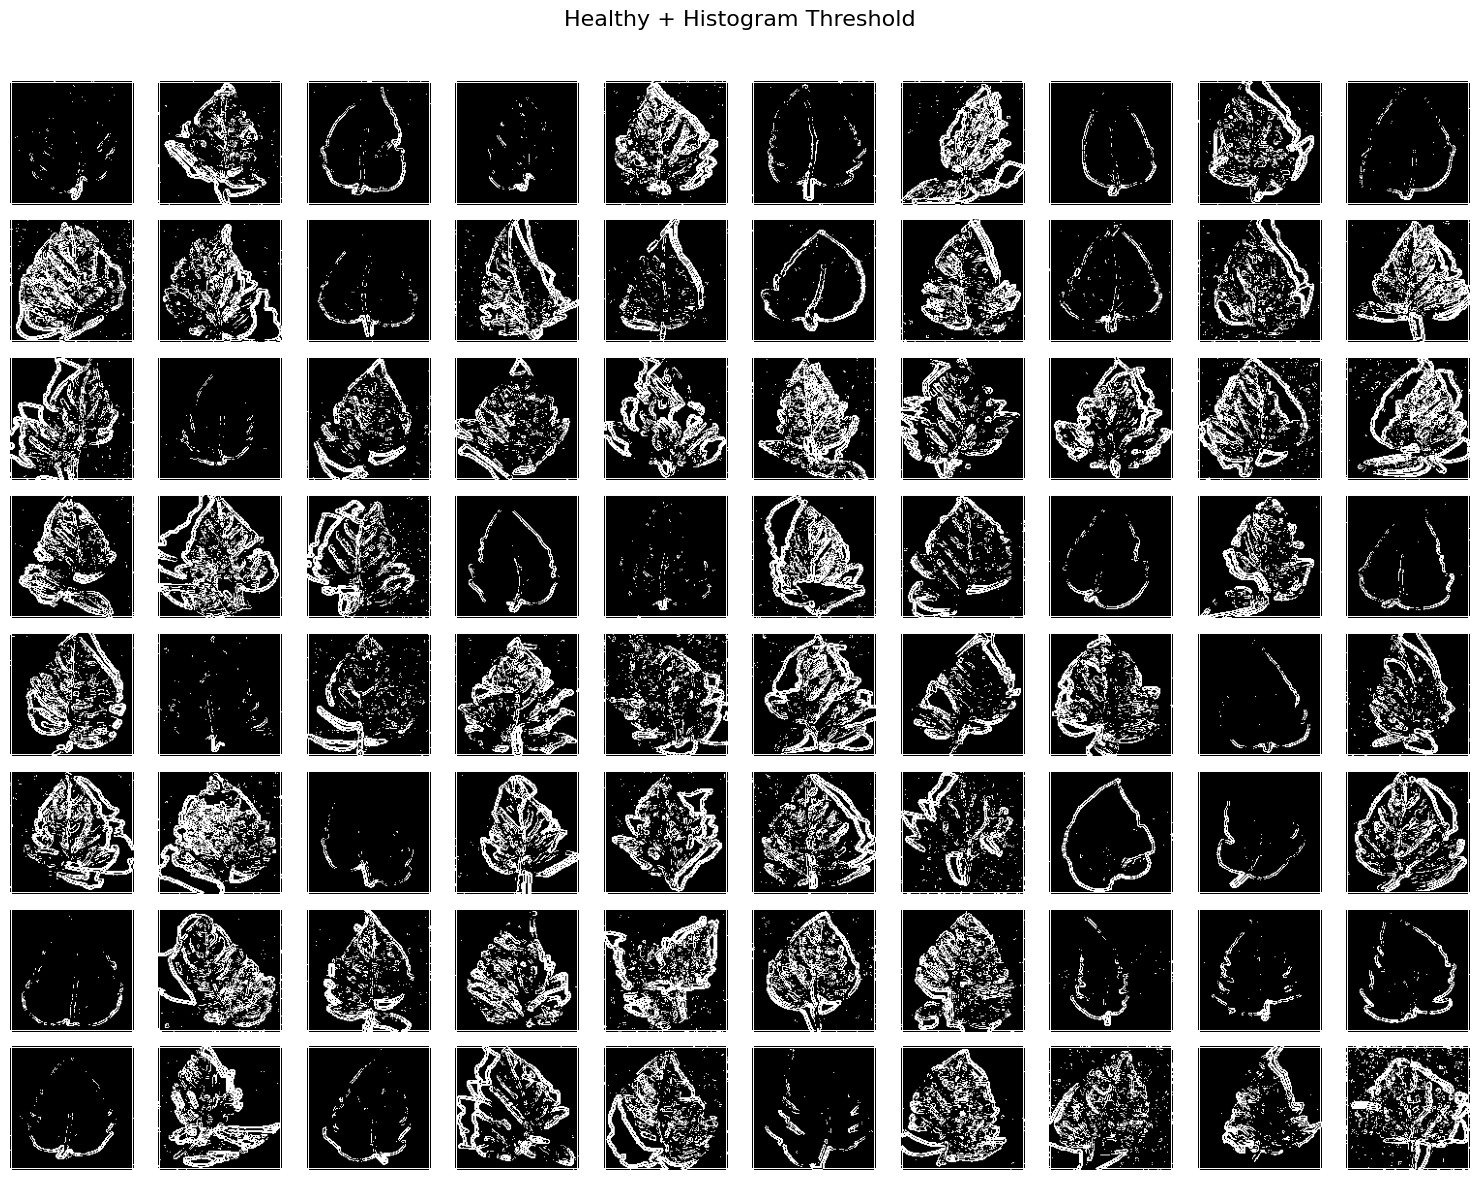

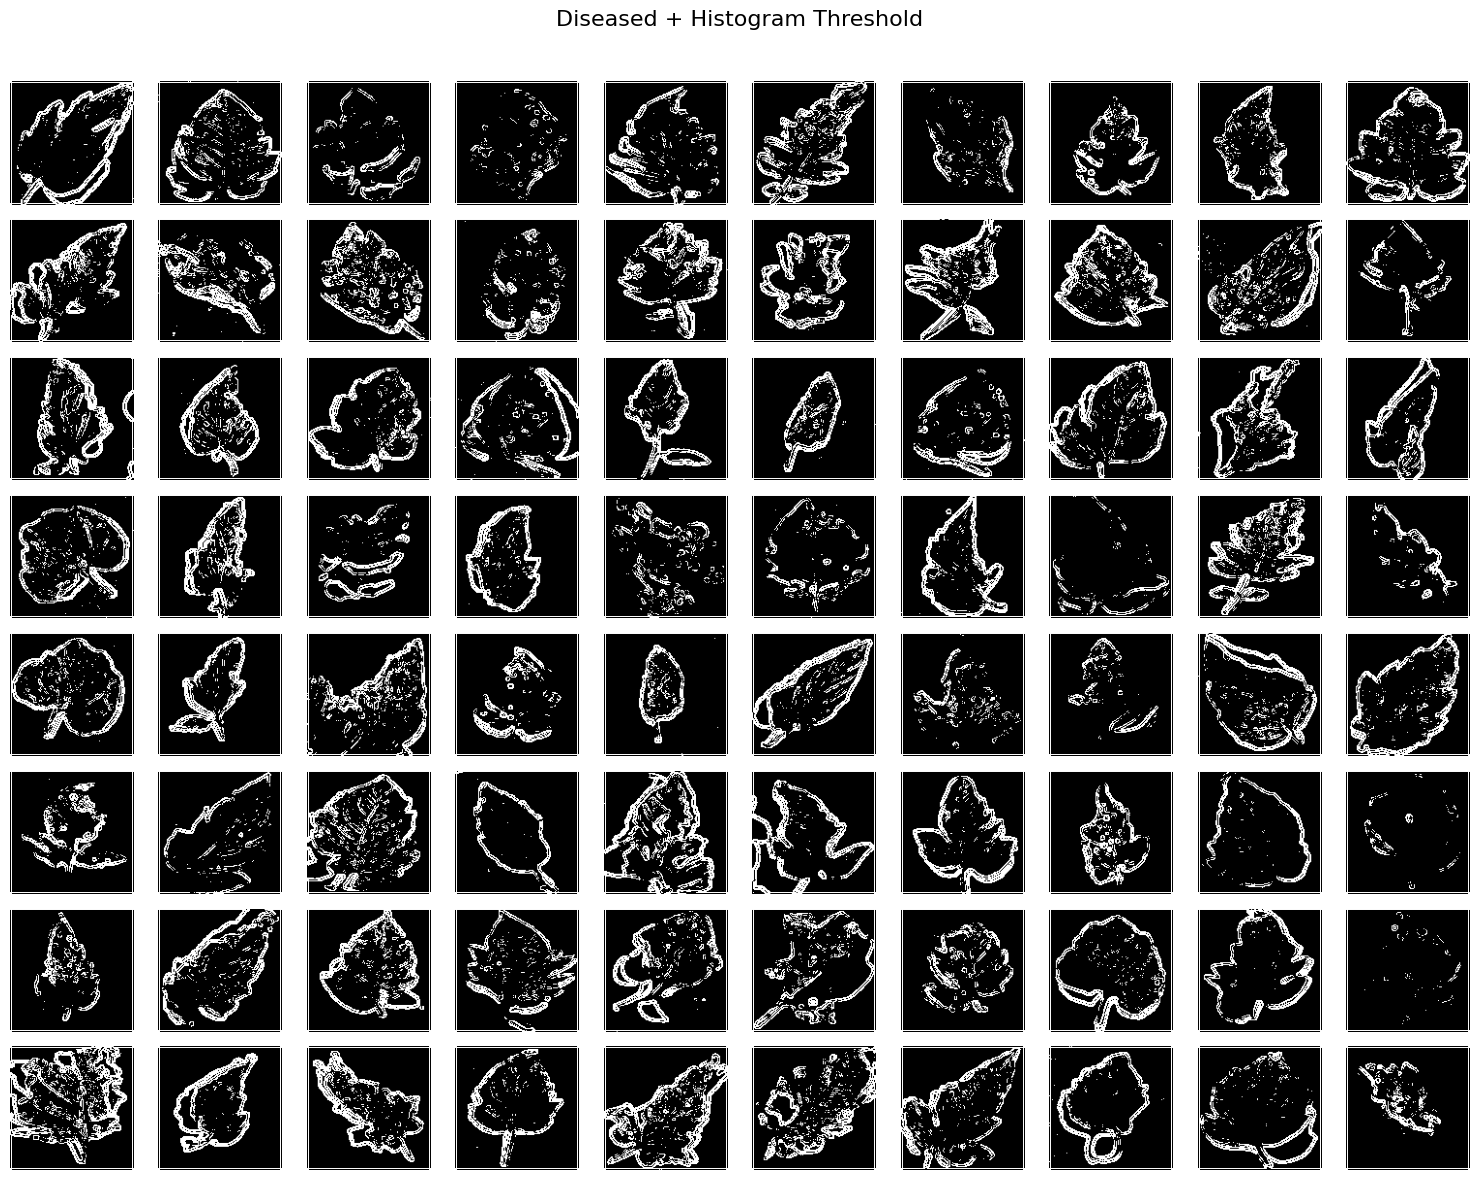

In [25]:
dataPreprocessed5 = [threshold(img, 40) for img in dataPreprocessed4]

def show_images_eq(idxs, title):
    fig, axs = plt.subplots(8, 10, figsize=(15, 12))
    fig.suptitle(title, fontsize=16)

    for k in range(len(idxs)):
        row = k // 10
        col = k % 10

        axs[row][col].imshow(dataPreprocessed5[idxs[k]], cmap='gray')
        axs[row][col].axis('off')

    # matikan subplot kosong
    for k in range(len(idxs), 80):
        row = k // 10
        col = k % 10
        axs[row][col].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

show_images_eq(healthy_idxs, "Healthy + Histogram Threshold")
show_images_eq(diseased_idxs, "Diseased + Histogram Threshold")

Kode di atas berfungsi untuk menerapkan fungsi `threshold` dengan nilai batas *40* menggunakan *list comprehension* pada seluruh citra hasil deteksi tepi Sobel (`dataPreprocessed4`), kemudian memanggil fungsi `show_images_eq` untuk menampilkan grid visualisasi gambar hitam-putih murni (biner) bagi masing-masing kategori kelas tanaman (*Healthy* dan *Diseased*), untuk memisahkan secara tegas objek garis tepi/pola penyakit dari latar belakangnya sebelum dilakukan analisis lebih lanjut.

# Menampilkan Ekstraksi Fitur GLCM

In [28]:
df3 = ekstrak_fitur_glcm(dataPreprocessed5, 'percobaan3')
display(df3)

,contrast,correlation,energy,homogeneity,dissimilarity,ASM,entropy,tahap
0,3680.056594,0.447947,0.918745,0.943406,14.431594,0.844092,0.375372,percobaan3
1,10052.154589,0.530823,0.734723,0.845413,39.420214,0.539819,0.901814,percobaan3
2,5524.084953,0.461178,0.874414,0.915048,21.663078,0.764599,0.525444,percobaan3
3,3360.051673,0.469169,0.923933,0.948328,13.176673,0.853653,0.356476,percobaan3
4,12736.195866,0.500891,0.670870,0.804137,49.945866,0.450066,1.045368,percobaan3
...,...,...,...,...,...,...,...,...
155,9164.140933,0.542454,0.755587,0.859070,35.937808,0.570911,0.851213,percobaan3
156,8748.134535,0.500359,0.783774,0.865467,34.306410,0.614301,0.783591,percobaan3
157,6456.099286,0.590711,0.817306,0.900715,25.318036,0.667989,0.688477,percobaan3
158,6560.100886,0.549770,0.827778,0.899116,25.725886,0.685216,0.662449,percobaan3


Kode di atas berfungsi untuk mengekstraksi fitur tekstur berdasarkan matriks ko-okurensi spasial piksel (GLCM) menggunakan fungsi `ekstrak_fitur_glcm` pada seluruh citra biner hasil segmentasi biner (`dataPreprocessed5`), melabeli outputnya sebagai data dari kelompok `'percobaan3'`, lalu menampilkannya dalam bentuk tabel data (DataFrame pandas) agar nilai statistik fitur teksturnya dapat dianalisis dengan mudah.

Kemudian, tabel tersebut menampilkan nilai statistik fitur tekstur dari 160 sampel citra biner hasil deteksi tepi Sobel dan *thresholding*, di mana nilai *Energy* dan *ASM* yang tinggi menunjukkan dominasi latar belakang hitam yang seragam, sementara variasi nilai *Contrast*, *Dissimilarity*, dan *Entropy* merepresentasikan tingkat kekasaran serta keacakan pola urat daun atau bercak gejala penyakit. Karakteristik parameter yang adaptif dan konsisten ini menjadi pembeda fitur yang kuat untuk memisahkan kelompok tanaman sehat dan sakit pada tahap klasifikasi *machine learning* selanjutnya.

In [29]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(dataPreprocessed5)):
    D0 = glcm(dataPreprocessed5[i], 0)
    D45 = glcm(dataPreprocessed5[i], 45)
    D90 = glcm(dataPreprocessed5[i], 90)
    D135 = glcm(dataPreprocessed5[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed5)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

for i in range(len(data)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

for i in range(len(data)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

for i in range(len(data)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

for i in range(len(data)):
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

for i in range(len(data)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

for i in range(len(data)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

Kode di atas berfungsi untuk mengekstraksi fitur tekstur GLCM (Gray-Level Co-occurrence Matrix) secara spesifik berdasarkan empat sudut orientasi spasial piksel, yaitu $0^\circ$, $45^\circ$, $90^\circ$, dan $135^\circ$. Proses diawali dengan pembentukan matriks kookurensi untuk masing-masing sudut pada setiap citra biner (`dataPreprocessed5`), yang kemudian diikuti oleh perhitungan tujuh parameter statistik tekstur—terdiri dari *correlation*, *contrast*, *dissimilarity*, *homogeneity*, *entropy*, *ASM*, dan *energy*—melalui perulangan (*looping*) terpisah untuk mengukur nilai spasial tekstur daun dari segala arah sudut pandang geometris secara detail sebelum dikonversi menjadi data fitur klasifikasi.

In [30]:
features = []

for i in range(len(dataPreprocessed5)):
    fitur = [
        contrast(Derajat0[i]), contrast(Derajat45[i]), contrast(Derajat90[i]), contrast(Derajat135[i]),
        dissimilarity(Derajat0[i]), dissimilarity(Derajat45[i]), dissimilarity(Derajat90[i]), dissimilarity(Derajat135[i]),
        homogenity(Derajat0[i]), homogenity(Derajat45[i]), homogenity(Derajat90[i]), homogenity(Derajat135[i]),
        entropyGlcm(Derajat0[i]), entropyGlcm(Derajat45[i]), entropyGlcm(Derajat90[i]), entropyGlcm(Derajat135[i]),
        ASM(Derajat0[i]), ASM(Derajat45[i]), ASM(Derajat90[i]), ASM(Derajat135[i]),
        energy(Derajat0[i]), energy(Derajat45[i]), energy(Derajat90[i]), energy(Derajat135[i]),
        correlation(Derajat0[i]), correlation(Derajat45[i]), correlation(Derajat90[i]), correlation(Derajat135[i]),
    ]
    features.append(fitur)

# Buat dataframe
columns = [
    "contrast_0", "contrast_45", "contrast_90", "contrast_135",
    "dissimilarity_0", "dissimilarity_45", "dissimilarity_90", "dissimilarity_135",
    "homogeneity_0", "homogeneity_45", "homogeneity_90", "homogeneity_135",
    "entropy_0", "entropy_45", "entropy_90", "entropy_135",
    "ASM_0", "ASM_45", "ASM_90", "ASM_135",
    "energy_0", "energy_45", "energy_90", "energy_135",
    "correlation_0", "correlation_45", "correlation_90", "correlation_135"
]

df_fitur = pd.DataFrame(features, columns=columns)

Kode di atas  untuk merangkum hasil ekstraksi 28 fitur tekstur GLCM dari setiap citra biner (`dataPreprocessed5`) dengan menggabungkan 7 parameter statistik (*contrast, dissimilarity, homogeneity, entropy, ASM, energy,* dan *correlation*) di seluruh arah sudut orientasi spasial ($0^\circ, 45^\circ, 90^\circ,$ dan $135^\circ$). Seluruh nilai matriks fitur tersebut dihimpun secara otomatis ke dalam baris dan dikonversi menjadi sebuah objek DataFrame Pandas (`df_fitur`) yang terstruktur rapi lengkap dengan penamaan kolom yang spesifik, sehingga siap digunakan sebagai kumpulan data input fitur (*feature set*) untuk tahap pemodelan *machine learning*.

In [31]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }

df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan3.csv', index=False)

hasilEkstrak3 = pd.read_csv('hasil_ekstraksi_percobaan3.csv')
hasilEkstrak3

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,000bf685-b305-408b-91f4-37030f8e62db___GH_HL L...,healthy,3680.056594,5765.128030,3480.053519,5523.234546,0.943406,0.911341,0.946482,0.915061,...,0.847049,0.819550,0.918745,0.903591,0.920352,0.905290,0.447947,0.136914,0.476830,0.173127
1,0d2bcda8-8dae-408e-8919-21dfa6cc9eea___RS_HL 0...,healthy,10052.154589,12896.954244,10192.156742,13945.159340,0.845413,0.801665,0.843260,0.785545,...,0.538444,0.500929,0.734723,0.714419,0.733787,0.707764,0.530823,0.400074,0.524133,0.351315
2,0b330273-890c-4995-af72-cba070fc0061___GH_HL L...,healthy,5524.084953,7849.443549,4856.074680,7720.433691,0.915048,0.879288,0.925321,0.881272,...,0.773589,0.737296,0.874414,0.857780,0.879539,0.858659,0.461178,0.236327,0.525262,0.248878
3,0c8c9c80-b7e0-47a7-81d3-b5a2174e545d___GH_HL L...,healthy,3360.051673,5176.520553,3160.048597,5474.855850,0.948328,0.920393,0.951403,0.915805,...,0.856420,0.825158,0.923933,0.910491,0.925430,0.908382,0.469169,0.185471,0.500766,0.138527
4,0a31e630-0d98-416b-b0e4-88a88aad1dc5___RS_HL 9...,healthy,12736.195866,15823.865398,12092.185962,15299.762850,0.804137,0.756653,0.814041,0.764713,...,0.456617,0.426404,0.670870,0.649771,0.675734,0.652996,0.500891,0.381837,0.525611,0.402311
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,1cffba8e-40e0-43ce-914b-c184feb2cb2e___Matt.S_...,diseased,9164.140933,13066.279683,9976.153420,12735.691921,0.859070,0.799061,0.846582,0.804145,...,0.560996,0.532862,0.755587,0.727871,0.748996,0.729974,0.542454,0.351045,0.503690,0.367464
156,1c721799-1ac2-47dd-8bc5-3f9414a34534___Matt.S_...,diseased,8748.134535,11631.045012,8280.127338,11026.311303,0.865467,0.821132,0.872664,0.830432,...,0.618904,0.588460,0.783774,0.763152,0.786705,0.767112,0.500359,0.339288,0.528332,0.373640
157,1c94b8af-21b7-43b5-b6ff-a5f7a3ad0a6e___Matt.S_...,diseased,6456.099286,9393.530287,6096.093750,9264.520429,0.900715,0.855542,0.906251,0.857526,...,0.672280,0.634002,0.817306,0.795353,0.819927,0.796242,0.590711,0.407516,0.613815,0.415653
158,1c9a19ab-15e6-4af9-9130-603a329f356e___Matt.S_...,diseased,6560.100886,9788.622977,7016.107899,9546.729493,0.899116,0.849466,0.892103,0.853186,...,0.679667,0.649436,0.827778,0.804253,0.824419,0.805876,0.549770,0.331849,0.518474,0.348360


Kode di atas untuk menyatukan nama file (`file_name`) dan label data (`labels`) bersama seluruh hasil kalkulasi 28 fitur tekstur GLCM dari empat sudut orientasi ($0^\circ, 45^\circ, 90^\circ,$ dan $135^\circ$) ke dalam sebuah struktur *dictionary* (`dataTable`), mengonversinya menjadi objek DataFrame Pandas, lalu mengekspornya secara permanen ke dalam format berkas CSV bernama `hasil_ekstraksi_percobaan3.csv` tanpa menyertakan indeks baris agar data tersebut tersimpan dengan aman dan siap dibaca kembali (`hasilEkstrak3`) untuk kebutuhan pemodelan atau klasifikasi di tahap selanjutnya.

# Correlation

<Axes: >

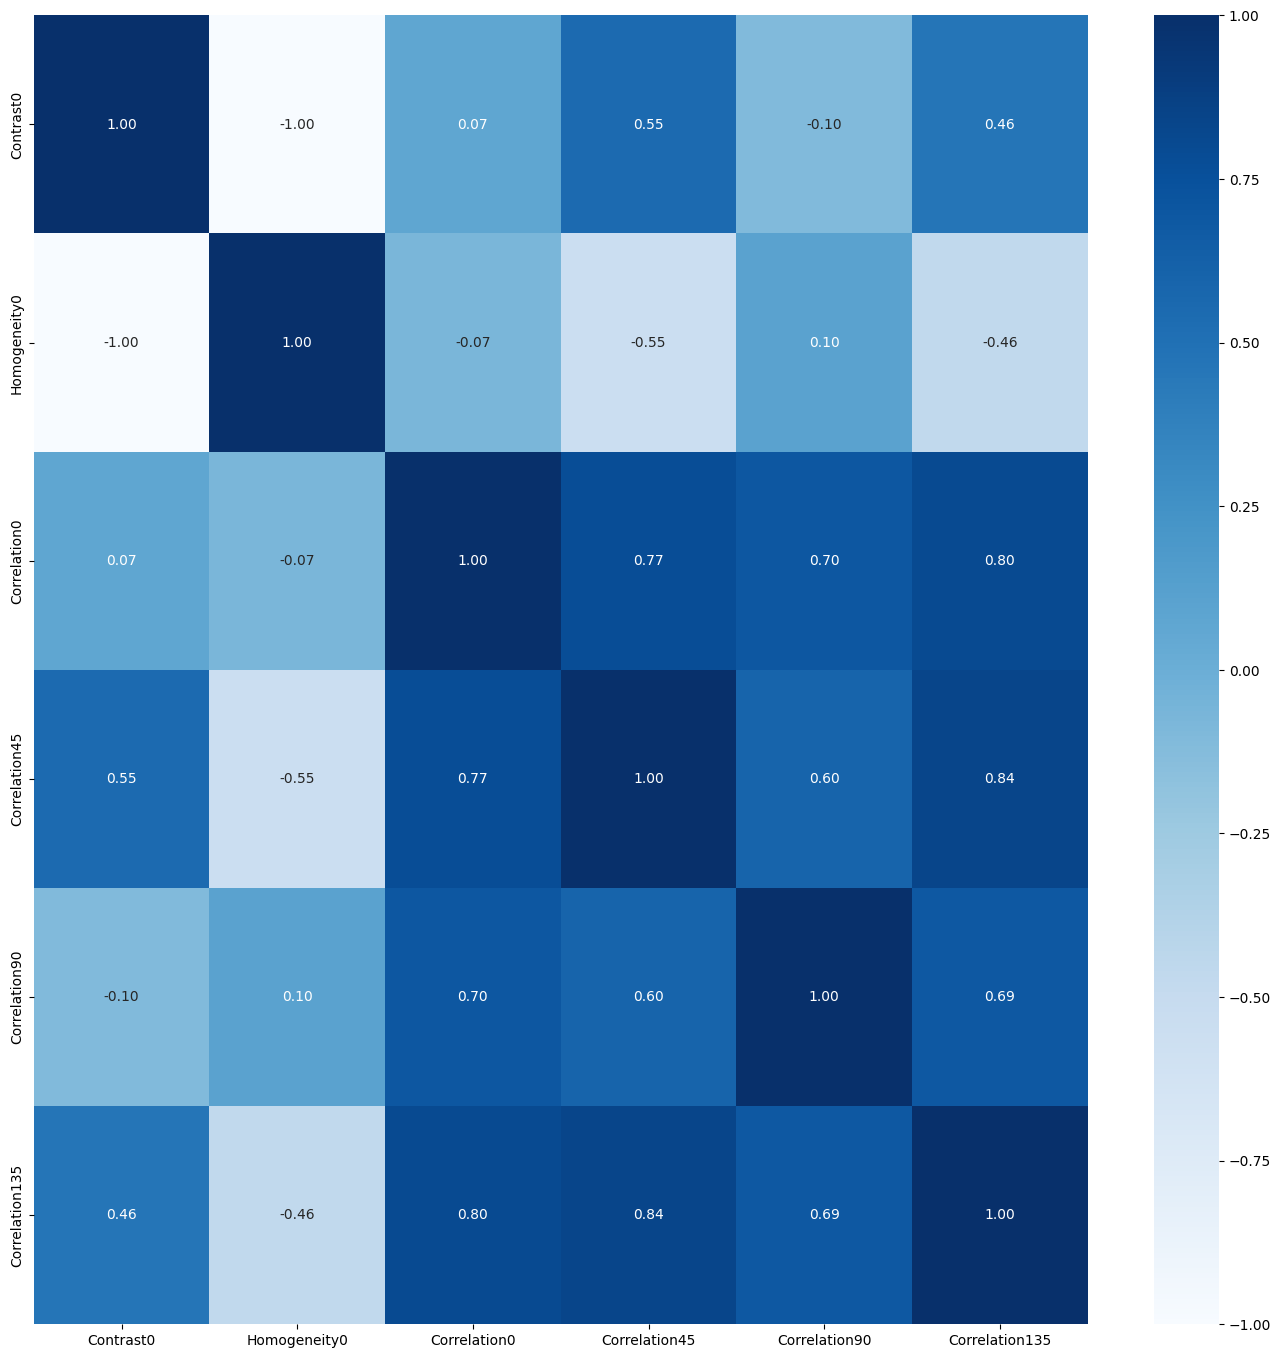

In [32]:
# Menghitung korelasi
correlation_matrix = hasilEkstrak3.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95 # atur threshold ini untuk menentukan seberapa besar korelasi yang ingin disaring
selectionFeature = []
columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)
for i in range(correlation_matrix.shape[0]):
	for j in range(i+1, correlation_matrix.shape[0]):
		if correlation_matrix.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False

select = hasilEkstrak3.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak3[select]
x_new
y = hasilEkstrak3['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")

Kode di atas untuk melakukan Seleksi Fitur (Feature Selection) berbasis matriks korelasi untuk mengatasi masalah multikolinieritas (redundancy data). Program menghitung nilai korelasi antar-fitur tekstur GLCM, lalu mendeteksi serta mengeliminasi fitur-fitur yang memiliki kemiripan informasi sangat tinggi (nilai korelasi $\ge 0.95$) agar menyisakan kumpulan fitur baru yang unik (x_new), yang kemudian divisualisasikan menggunakan heatmap berukuran 17×17 inci untuk mempermudah analisis persebaran korelasi fitur sebelum masuk ke tahap pemodelan machine learning.

# Split Data

In [33]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(128, 6)
(32, 6)
(128,)
(32,)


Kode di atas untuk membagi kumpulan fitur yang telah diseleksi (x_new) dan label target (y) menjadi dua bagian terpisah, yaitu data latih (training set) dan data uji (testing set), menggunakan fungsi train_test_split.

Dengan menentukan test_size=0.2, dataset dialokasikan sebesar 80% untuk data latih (digunakan algoritma machine learning untuk mengenali dan mempelajari pola fitur tekstur daun) dan 20% untuk data uji (digunakan sebagai data baru untuk mengevaluasi performa akurasi model). Parameter random_state=42 disematkan guna mengunci pola pengacakan baris data secara konsisten, sehingga hasil pembagian data serta ukuran dimensi matriks yang dicetak lewat perintah print(shape) akan selalu sama setiap kali program dijalankan kembali.

# Normalization

In [34]:
# normalisasi mean std (Standardization / Z-score normalization)

X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

Kode di atas untuk melakukan standardisasi skala data (*Z-score normalization*) pada fitur data latih dan data uji agar seluruh parameter tekstur GLCM memiliki nilai rata-rata nol dan standar deviasi satu. Proses penyetaraan skala ini sangat penting untuk mencegah fitur yang memiliki rentang nilai besar (seperti *Contrast*) mendominasi fitur berangka kecil (seperti *Homogeneity*) saat proses perhitungan algoritma klasifikasi. Selain itu, penggunaan nilai rata-rata (`mean`) dan standar deviasi (`std`) dari `X_train` untuk mentransformasi `X_test` bertujuan untuk menghindari kebocoran data (*data leakage*), sehingga menjaga pengujian model tetap objektif dan valid.

# Hasil Evaluasi

In [35]:
rf3 = RandomForestClassifier(n_estimators=5, random_state=42)
svm3 = SVC(kernel='rbf', random_state=42)
knn3 = KNeighborsClassifier(n_neighbors=5)

Kode di atas untuk menginisialisasi tiga model klasifikasi *machine learning*—yaitu **Random Forest** (dengan 5 pohon keputusan), **Support Vector Machine** (menggunakan kernel RBF untuk pemisahan data non-linier), dan **K-Nearest Neighbors** (berdasarkan voting dari 5 tetangga terdekat)—yang akan digunakan untuk memprediksi kondisi kesehatan daun tanaman. Inisialisasi beberapa algoritma ini secara bersamaan pada Percobaan 3 bertujuan untuk melakukan analisis komparatif performa model, sehingga nantinya dapat dievaluasi dan dipilih algoritma mana yang paling akurat dalam mengenali pola karakteristik fitur tekstur GLCM antara kelas tanaman sehat (*Healthy*) dan sakit (*Diseased*).

In [37]:
# Train Random Forest Classifier
rf3.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf3.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf3.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

    diseased       1.00      0.94      0.97        64
     healthy       0.94      1.00      0.97        64

    accuracy                           0.97       128
   macro avg       0.97      0.97      0.97       128
weighted avg       0.97      0.97      0.97       128

[[60  4]
 [ 0 64]]
Accuracy: 0.96875

------Testing Set------
              precision    recall  f1-score   support

    diseased       0.83      0.94      0.88        16
     healthy       0.93      0.81      0.87        16

    accuracy                           0.88        32
   macro avg       0.88      0.88      0.87        32
weighted avg       0.88      0.88      0.87        32

[[15  1]
 [ 3 13]]
Accuracy: 0.875


Kode di atas untuk melatih (training) model klasifikasi Random Forest (rf3) menggunakan pasangan data latih beserta labelnya (X_train, y_train), kemudian langsung mengevaluasi performa prediksinya pada dua skenario kelompok data yang berbeda. Menggunakan fungsi kustom generateClassificationReport, program akan menghitung dan menampilkan metrik evaluasi klasifikasi (seperti accuracy, precision, recall, dan F1-score) baik untuk data latih maupun data uji (X_test). Pengujian di kedua sisi ini bertujuan untuk mendeteksi kualitas model secara objektif; perbandingan hasil metrik antara Training Set dan Testing Set akan menunjukkan apakah model Random Forest yang dibuat sudah optimal, mengalami underfitting, atau justru mengalami overfitting (menghafal data latih namun gagal memprediksi data uji dengan baik).

In [38]:
# Train SVM Classifier
svm3.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm3.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm3.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

    diseased       0.90      0.89      0.90        64
     healthy       0.89      0.91      0.90        64

    accuracy                           0.90       128
   macro avg       0.90      0.90      0.90       128
weighted avg       0.90      0.90      0.90       128

[[57  7]
 [ 6 58]]
Accuracy: 0.8984375

------Testing Set------
              precision    recall  f1-score   support

    diseased       0.89      1.00      0.94        16
     healthy       1.00      0.88      0.93        16

    accuracy                           0.94        32
   macro avg       0.94      0.94      0.94        32
weighted avg       0.94      0.94      0.94        32

[[16  0]
 [ 2 14]]
Accuracy: 0.9375


Kode di atas untuk melatih (training) model klasifikasi Support Vector Machine (svm3) menggunakan fungsi .fit() pada data latih beserta labelnya, kemudian menguji performa prediksinya secara terpisah pada kelompok data latih (Training Set) dan data uji (Testing Set). Proses evaluasi ini dilakukan dengan memanggil fungsi kustom generateClassificationReport untuk mengukur tingkat keberhasilan model dalam memisahkan pola kelas daun sehat dan sakit berdasarkan metrik performa statistik (seperti accuracy, precision, recall, dan F1-score). Pengujian ganda pada kedua kelompok data ini bertujuan untuk memvalidasi kemampuan generalisasi model SVM ber-kernel RBF tersebut, sekaligus mengidentifikasi ada atau tidaknya indikasi overfitting maupun underfitting sebelum model diandalkan sepenuhnya.

In [39]:
# Train KNN Classifier
knn3.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn3.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn3.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

    diseased       0.93      0.84      0.89        64
     healthy       0.86      0.94      0.90        64

    accuracy                           0.89       128
   macro avg       0.89      0.89      0.89       128
weighted avg       0.89      0.89      0.89       128

[[54 10]
 [ 4 60]]
Accuracy: 0.890625

------Testing Set------
              precision    recall  f1-score   support

    diseased       0.94      0.94      0.94        16
     healthy       0.94      0.94      0.94        16

    accuracy                           0.94        32
   macro avg       0.94      0.94      0.94        32
weighted avg       0.94      0.94      0.94        32

[[15  1]
 [ 1 15]]
Accuracy: 0.9375


Kode di atas untuk melatih (*training*) model klasifikasi **K-Nearest Neighbors** (`knn3`) menggunakan data latih dan labelnya, kemudian langsung mengevaluasi performa prediksinya secara terpisah pada kelompok data latih (*Training Set*) dan data uji (*Testing Set*). Proses evaluasi dijalankan melalui fungsi kustom `generateClassificationReport` untuk menghasilkan metrik performa statistik seperti akurasi, presisi, *recall*, dan *F1-score*. Tujuan pengujian ganda ini adalah untuk mengukur efektivitas algoritma KNN dalam mengelompokkan daun berdasarkan kedekatan jarak fitur tekstur GLCM-nya, sekaligus mendeteksi ada atau tidaknya indikasi *overfitting* atau *underfitting* pada model tersebut.

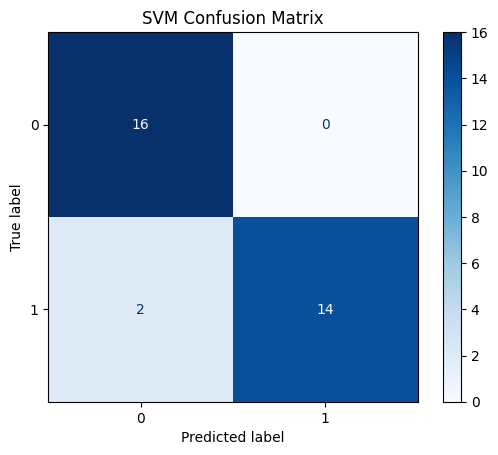

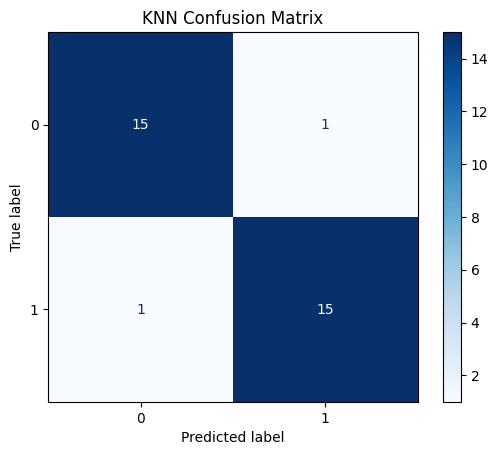

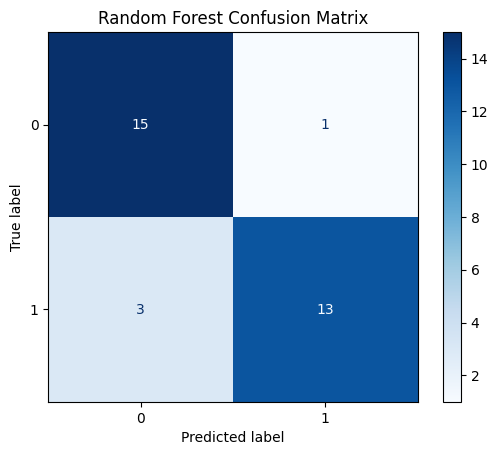

In [40]:
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm3.predict(X_test), "SVM Confusion Matrix")

# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn3.predict(X_test), "KNN Confusion Matrix")

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf3.predict(X_test), "Random Forest Confusion Matrix")

Kode di atas untuk menggambarkan grafis Confusion Matrix dari ketiga model klasifikasi (Support Vector Machine, K-Nearest Neighbors, dan Random Forest) yang telah diuji menggunakan data evaluasi (X_test dan y_test).

Melalui fungsi kustom plot_confusion_matrix, program akan menampilkan matriks dua dimensi yang memetakan jumlah data aktual (label asli daun tanaman) terhadap hasil prediksi yang dikeluarkan oleh masing-masing model. Visualisasi ini sangat krusial dalam analisis kesalahan (error analysis) karena tidak hanya memperlihatkan tingkat akurasi global, melainkan juga merinci secara transparan seberapa banyak sampel daun sehat yang salah diprediksi sebagai sakit (False Positive) serta seberapa banyak sampel daun sakit yang luput dan justru terprediksi sebagai sehat (False Negative) untuk setiap algoritma di Percobaan 3 ini.

# Tabel Perbandingan

In [42]:
# Display model comparison
rf_pred = rf3.predict(X_test)
svm_pred = svm3.predict(X_test)
knn_pred = knn3.predict(X_test)
display_model_comparison(y_test, rf_pred, svm_pred, knn_pred)


TABEL PERBANDINGAN MODEL


,Accuracy,Precision,Recall,F1-Score
Random Forest,0.8750,0.880952,0.8750,0.874510
SVM,0.9375,0.944444,0.9375,0.937255
KNN,0.9375,0.937500,0.9375,0.937500


Kode di atas dari fungsi display_model_comparison untuk merangkum dan membandingkan hasil prediksi akhir dari ketiga algoritma (Random Forest, SVM, dan KNN) pada data uji secara simultan.

Fungsi ini melakukan ekstraksi metrik evaluasi standar secara otomatis meliputi Accuracy, Precision, Recall, dan F1-Score (dengan pembobotan weighted average untuk menangani potensi ketidakseimbangan data) lalu menyusun hasilnya ke dalam satu objek DataFrame Pandas yang ditranspose (.T). Langkah penutupan ini bertujuan untuk menyajikan ringkasan performa komparatif yang rapi dan scannable dalam bentuk tabel tunggal, sehingga Anda dapat melakukan analisis akhir secara objektif untuk menentukan algoritma machine learning terbaik yang paling optimal dalam mengklasifikasikan fitur tekstur citra biner daun.